In [1]:
 # Required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


In [19]:
NN_PATH = "NN_all_out.csv"

def read_features(path):
    """Read a feature file whether it is tab-, ';'- or ','-separated."""
    for sep in ["\t", ";", ","]:
        d = pd.read_csv(path, sep=sep)
        if d.shape[1] > 1:
            return d
    return d

NN = read_features(NN_PATH)
NN = NN.drop(columns=["Unnamed: 0", "sentlength", "alang", "akorp", "afile", "astatus"], errors="ignore")

In [20]:
df = NN
df

,sentlength,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,17.000000,0.098039,0.049020,0.00,0.666667,0.0,0.333333,0.166667,0.0,0.000000,...,3.215639,1.321968,0.033333,0.344444,0.066667,0.180556,0.066667,0.000000,0.141667,fr
1,18.666667,0.089286,0.017857,0.00,0.666667,0.0,0.666667,0.000000,0.0,0.666667,...,2.961601,1.692810,0.000000,0.222222,0.000000,0.000000,0.000000,0.000000,0.444444,fr
2,25.000000,0.080000,0.020000,0.02,0.500000,0.0,0.500000,0.000000,0.0,0.000000,...,3.412162,1.295045,0.000000,0.214286,0.071429,0.142857,0.071429,0.000000,0.000000,fr
3,22.800000,0.052632,0.035088,0.00,0.800000,0.2,0.400000,0.000000,0.0,0.200000,...,3.289324,1.505121,0.028571,0.240000,0.165714,0.000000,0.165714,0.000000,0.200000,fr
4,15.750000,0.126984,0.000000,0.00,0.500000,0.0,0.000000,0.000000,0.0,0.000000,...,3.121032,1.225694,0.000000,0.604167,0.125000,0.062500,0.125000,0.000000,0.083333,fr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,67.000000,0.074627,0.007463,0.00,2.500000,0.0,0.000000,0.000000,0.0,0.500000,...,4.406695,2.681624,0.142857,0.428571,0.142857,0.071429,0.142857,0.000000,0.071429,de
315,5.000000,0.000000,0.000000,0.00,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de
316,39.500000,0.113924,0.037975,0.00,1.000000,0.5,0.500000,0.000000,0.0,1.000000,...,3.893436,1.869112,0.000000,0.450000,0.000000,0.100000,0.000000,0.100000,0.350000,de
317,16.333333,0.102041,0.000000,0.00,0.333333,0.0,0.333333,0.000000,0.0,0.333333,...,3.336700,1.213292,0.111111,0.555556,0.000000,0.000000,0.000000,0.000000,0.000000,de


In [22]:


num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

df

Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,attrib,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,0.098039,0.049020,0.00,0.666667,0.0,0.333333,0.166667,0.0,0.000000,0.166667,...,3.215639,1.321968,0.033333,0.344444,0.066667,0.180556,0.066667,0.000000,0.141667,fr
1,0.089286,0.017857,0.00,0.666667,0.0,0.666667,0.000000,0.0,0.666667,1.000000,...,2.961601,1.692810,0.000000,0.222222,0.000000,0.000000,0.000000,0.000000,0.444444,fr
2,0.080000,0.020000,0.02,0.500000,0.0,0.500000,0.000000,0.0,0.000000,1.500000,...,3.412162,1.295045,0.000000,0.214286,0.071429,0.142857,0.071429,0.000000,0.000000,fr
3,0.052632,0.035088,0.00,0.800000,0.2,0.400000,0.000000,0.0,0.200000,1.000000,...,3.289324,1.505121,0.028571,0.240000,0.165714,0.000000,0.165714,0.000000,0.200000,fr
4,0.126984,0.000000,0.00,0.500000,0.0,0.000000,0.000000,0.0,0.000000,0.500000,...,3.121032,1.225694,0.000000,0.604167,0.125000,0.062500,0.125000,0.000000,0.083333,fr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,0.074627,0.007463,0.00,2.500000,0.0,0.000000,0.000000,0.0,0.500000,5.000000,...,4.406695,2.681624,0.142857,0.428571,0.142857,0.071429,0.142857,0.000000,0.071429,de
315,0.000000,0.000000,0.00,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de
316,0.113924,0.037975,0.00,1.000000,0.5,0.500000,0.000000,0.0,1.000000,3.500000,...,3.893436,1.869112,0.000000,0.450000,0.000000,0.100000,0.000000,0.100000,0.350000,de
317,0.102041,0.000000,0.00,0.333333,0.0,0.333333,0.000000,0.0,0.333333,1.333333,...,3.336700,1.213292,0.111111,0.555556,0.000000,0.000000,0.000000,0.000000,0.000000,de


Clustering Accuracy: 0.3225806451612903
Pred  de  es  fr
True            
de    25   4   2
es    23   6   2
fr    21   1   9
it    25   4   2

Classification Report:
               precision    recall  f1-score   support

          de     0.2660    0.8065    0.4000        31
          es     0.4000    0.1935    0.2609        31
          fr     0.6000    0.2903    0.3913        31
          it     0.0000    0.0000    0.0000        31

    accuracy                         0.3226       124
   macro avg     0.3165    0.3226    0.2630       124
weighted avg     0.3165    0.3226    0.2630       124



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


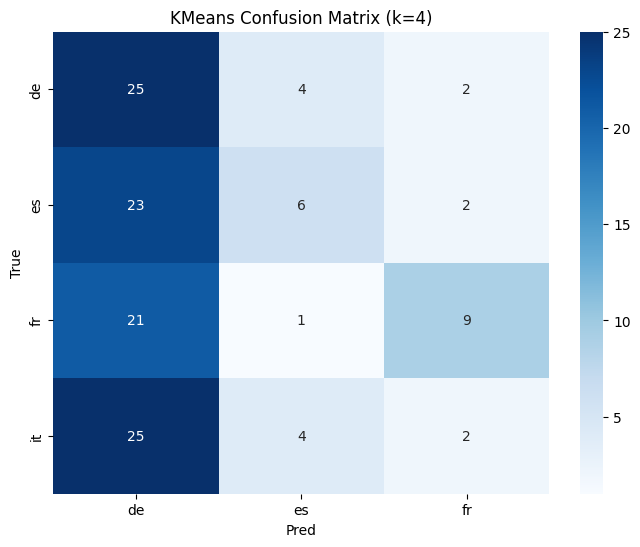

In [24]:

df = (
    df
    .groupby('L1', group_keys=False)
    .sample(n=31, random_state=42)
)


def run_kmeans_evaluation(df, n_clusters=4, label_col='L1', drop_cols=None, plot=True):

    df = df.dropna().copy()

    # Drop non-feature columns
    if drop_cols is not None:
        df_features = df.drop(drop_cols, axis=1)
    else:
        df_features = df.copy()

    X = df_features.values

    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['cluster'] = kmeans.fit_predict(X)

    y_true = df[label_col].values
    y_pred = df['cluster'].values

    # Map clusters to majority labels
    labels = np.empty_like(y_pred, dtype=object)
    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        unique_labels, counts = np.unique(y_true[mask], return_counts=True)
        labels[mask] = unique_labels[np.argmax(counts)]

    # Metrics
    accuracy = accuracy_score(y_true, labels)
    print("Clustering Accuracy:", accuracy)

    confusion_matrix = pd.crosstab(y_true, labels, rownames=['True'], colnames=['Pred'])
    print(confusion_matrix)

    print("\nClassification Report:\n", classification_report(y_true, labels, digits=4))

    # Plot
    if plot:
        plt.figure(figsize=(8,6))
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title(f'KMeans Confusion Matrix (k={n_clusters})')
        plt.show()

    # Clean up
    df = df.drop('cluster', axis=1)

    return df, accuracy, confusion_matrix

df, acc, cm = run_kmeans_evaluation(
    df,
    n_clusters=4,
    label_col='L1',
    drop_cols=[ 'L1']
)

In [25]:
df

,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,attrib,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
251,0.009479,0.003160,0.000000,1.045455,0.000000,0.272727,0.000000,0.0,0.318182,2.772727,...,3.754582,1.584193,0.165117,0.341942,0.084022,0.060950,0.074552,0.008264,0.037879,de
309,0.050633,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.0,1.500000,3.500000,...,4.704762,2.011111,0.250000,0.416667,0.000000,0.000000,0.000000,0.083333,0.250000,de
265,0.036723,0.016949,0.000000,0.642857,0.142857,0.642857,0.071429,0.0,0.285714,1.785714,...,4.031942,1.189286,0.035714,0.254762,0.089286,0.050000,0.089286,0.000000,0.338095,de
247,0.071429,0.035714,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,...,3.958333,1.375000,0.333333,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,de
275,0.021127,0.014085,0.000000,0.285714,0.000000,0.000000,0.000000,0.0,0.285714,1.428571,...,3.231627,1.534797,0.000000,0.000000,0.000000,0.142857,0.000000,0.000000,0.428571,de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,0.015974,0.009585,0.003195,0.600000,0.000000,0.400000,0.000000,0.0,0.300000,2.800000,...,4.018704,1.893023,0.203333,0.261667,0.075000,0.140000,0.050000,0.020000,0.050000,it
85,0.045113,0.018797,0.000000,1.090909,0.090909,0.272727,0.000000,0.0,0.454545,1.181818,...,3.470266,1.419002,0.018182,0.522727,0.018182,0.093939,0.018182,0.000000,0.146970,it
86,0.016611,0.013289,0.003322,2.500000,0.166667,0.166667,0.000000,0.0,0.333333,4.500000,...,4.805853,1.750977,0.400000,0.116667,0.083333,0.083333,0.083333,0.033333,0.200000,it
78,0.006098,0.012195,0.000000,2.000000,0.285714,0.142857,0.000000,0.0,0.714286,5.857143,...,4.007536,1.952890,0.255102,0.336735,0.040816,0.000000,0.040816,0.020408,0.020408,it


Accuracy: 0.2
              precision    recall  f1-score   support

          de       0.23      0.83      0.36         6
          es       0.00      0.00      0.00         6
          fr       0.00      0.00      0.00         7
          it       0.00      0.00      0.00         6

    accuracy                           0.20        25
   macro avg       0.06      0.21      0.09        25
weighted avg       0.05      0.20      0.09        25



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


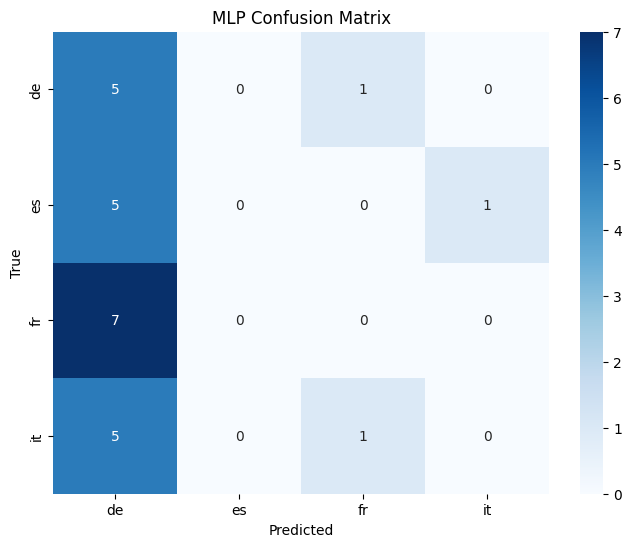

In [26]:

feature_cols = [c for c in df.columns if c != 'L1']

X = df[feature_cols].to_numpy(dtype=np.float64)
y = df['L1'].to_numpy()
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # converts ['de', 'es', 'fr', 'it'] → [0, 1, 2, 3]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fit MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_s, y_train)

# Predictions
y_pred = mlp.predict(X_test_s)

# Decode labels for reporting (optional)
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)


print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

# Confusion matrix
labels_order = le.classes_
conf_mat = confusion_matrix(y_test_labels, y_pred_labels, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [27]:
# idea zero shot on text itself if LLM can identify the shining through.